In [94]:
from email.mime import image
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import time
import json
import re
# import nltk
# nltk.download('stopwords')
# nltk.download('punkt')
# from nltk.corpus import stopwords
# from nltk.tokenize import word_tokenize, sent_tokenize

def to_json(data):
    """
    This function takes list of dictionary as Input and 
    then Creates a JSON file in which Input data is stored
    """
    with open("data_dict.json", "w") as outfile:
        json.dump(data, outfile,indent=4)
        outfile.close()

In [121]:
def get_data(slug_name):
    data_list = []
    url = "http://www.hcmc.gr/en_US/web/portal/cv"
    options = webdriver.ChromeOptions()
    options.add_argument("--start-maximized") 
    options.add_argument("--disable-blink-features=AutomationControlled")
    options.add_argument("--log-level=3")

    driver = webdriver.Chrome(options=options)
    driver.get(url)
    totalMembers = driver.find_elements(By.XPATH, f'//ul[@class="layouts level-1"]/li/a')
    links = [i.get_attribute("href") for i in totalMembers]
    # print(links)
    for i in links:
    #     people = driver.find_element(By.XPATH, f'//ul[@class="layouts level-1"]/li[{i}]/a').get_attribute("href")
        driver.get(i)
        time.sleep(3)
        try:
            data_dict = {}
            name = driver.find_element(By.XPATH, f"//div[2]/div/h1").text
            if "-" in name:
                name = name.split("-")
                position = name[1].strip()
                name  = name[0] 
            if "," in name:
                name = name.split(",")
                position = name[1].strip()
                name  = name[0]
#             print(name)
            data_dict['fullName'] = name
#             print(position)
            data_dict['position'] = position
            try:
                image = driver.find_element(By.XPATH, f'//div/div/div[1]/p/img').get_attribute("src")
#                 print(image)
                data_dict['image'] = image
            except:
                image = driver.find_element(By.XPATH, f'//div/div[1]/h2[1]/img').get_attribute("src")
#                 print(image)
                data_dict['image'] = image
            positions = driver.find_elements(By.XPATH, f"//div/div/div/div/div[1]/p")
        
            additionalInfo = ""
            for p in positions:
                if len(p.text.strip()):
                    additionalInfo += p.text.strip() + "; "
#                 print(additionalInfo)
            data_dict['careerInfo'] = additionalInfo

#             print(name)
#             print(position)
#             print(careerInfo)
#             if name:
#                 data_dict['fullName'] = name
#                 if position:
#                     data_dict['position'] = position
#                 if image:
#                     data_dict['image'] = image
#                 if carrerInfo:
#                     data_dict['careerInfo'] = careerInfo
        except:
            pass
        data_list.append(data_dict)
    return data_list

In [122]:
if __name__ == '__main__':
    data_list = get_data("add_slug_name")
    to_json(data_list)

[{'fullName': 'Vassiliki Lazarakou ', 'position': 'Chair', 'image': 'http://www.hcmc.gr/aweb/files/cv_ds/vas-laz-110121.png', 'careerInfo': 'Vassiliki Lazarakou, JSD; Chair of the Hellenic Capital Market Commission (HCMC); Member of the Management Board of the European Securities and Markets Authority (ESMA); Chair of ESAs Joint Committee Securitisation Committee; Vassiliki Lazarakou is the Chair of the HCMC and member of ESMA’s Board of Supervisors. On 16/12/2020, Vassiliki Lazarakou was elected member of ESMA’s Management Board for the time period from 1/1/2021-30/6/2023. She has been elected, by the Boards of the three ESAs (ESMA, EBA & EIOPA), as chair of the ESAs Joint Committee Securitisation Committee.; She is a lawyer, admitted to both Athens Bar (Supreme Court Lawyer) and New York Bar, USA. She is an expert in capital markets, banking and finance law as well as in M&As and has led a large number of international and domestic business transactions.; She has a Doctorate in Law (
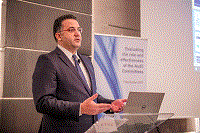
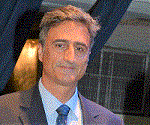
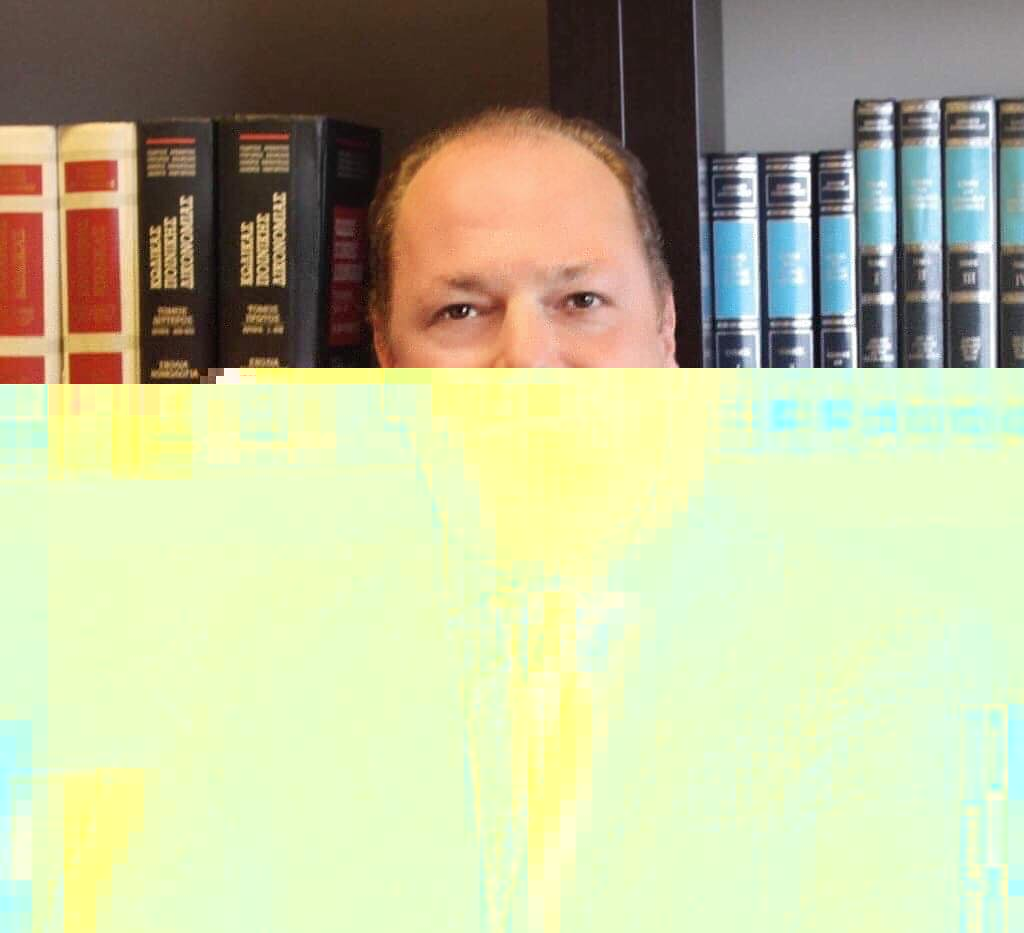

In [123]:
print(data_list)